# KKBox Music Recommendation: Building a Collaborative-Filtering Predictor

For the second half of this project I wanted to try the other kind of
recommendation problem — one where I actually have real user behavior
to learn from, instead of just item properties. I used Kaggle's real
[WSDM - KKBox's Music Recommendation
Challenge](https://www.kaggle.com/competitions/kkbox-music-recommendation-challenge):
given a real member's listening history and a specific song, predict
whether they'll listen to it again within a month of first hearing it.

This is the deliberate opposite of the content-based approach in this
project's companion notebook, `01_content_based.ipynb`, which compares
tracks by their own audio features and needs no user data at all. Here,
the entire task is defined by real user/song interaction history — I
don't even have audio features for most of these songs — and it's
scored by AUC on a real Kaggle leaderboard, which meant I could actually
check my results against a public benchmark instead of just my own
intuition.

**Before running:** download and extract the competition data (six
`.csv.7z` files) — see the project README's "Get the data" section.

## What I wanted to figure out

1. Why **collaborative filtering** needs real interaction data, unlike
   the content-based approach in Part I
2. How to encode identity columns too high-cardinality to one-hot encode
   (`artist_name`: 222,363 distinct values)
3. What real-world **data-quality investigation** actually turns up when
   I stop assuming a column is clean and check it
4. What **AUC** measures, and why one honest holdout split beats k-fold
   CV once a single fit already takes real time
5. Whether a genuine **scalability tradeoff** shows up when I measure it
   directly, rather than assume it
6. What **SHAP** looks like on a binary classifier, compared to the
   multiclass case in Part I

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from recommendation_showcase.collaborative import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
train = data.load_train()
print(f"{len(train)} training interactions")
train.head()

7377418 training interactions


,msno,song_id,source_system_tab,source_screen_name,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1


### Why this is collaborative filtering, not content-based

The companion notebook, `01_content_based.ipynb`, recommends by
comparing tracks' *own* audio features — no user data needed at all.
This dataset flips that completely: the entire task is defined by real
user/song interaction history (`msno`, `song_id`, and whether the user
replayed it). There's simply no way to answer "will this user replay
this song" from the song's audio alone — it depends on *this specific
user's* behavior and history, which is exactly the gap collaborative
filtering is built to fill.

In [3]:
songs = data.load_songs()
members = data.load_members()
song_extra = data.load_song_extra_info()
print(f"{len(songs)} songs, {len(members)} members, {len(song_extra)} extra-info rows")
songs.head()

2296320 songs, 34403 members, 2295971 extra-info rows


,song_id,song_length,genre_ids,artist_name,composer,lyricist,language
0,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,247640,465,張信哲 (Jeff Chang),董貞,何啟弘,3.0
1,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=,197328,444,BLACKPINK,TEDDY| FUTURE BOUNCE| Bekuh BOOM,TEDDY,31.0
2,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=,231781,465,SUPER JUNIOR,NaN,NaN,31.0
3,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=,273554,465,S.H.E,湯小康,徐世珍,3.0
4,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=,140329,726,貴族精選,Traditional,Traditional,52.0


## 2. Real data-quality investigation

### Lesson learned: verify, don't assume

I almost trusted `bd` (birthdate-derived age) at face value — it *looks*
like a clean numeric feature. Checking it directly told me a very
different story, and it's a habit I kept for the rest of this dataset:
check every column before trusting it, rather than assume a numeric
column means what its name suggests.

In [4]:
print(members["bd"].describe())
low, high = config.VALID_AGE_RANGE
garbage_share = (~members["bd"].between(low, high)).mean()
print(f"\nShare of members with bd outside {low}-{high}: {garbage_share:.1%}")

count    34403.000000
mean        12.280935
std         18.170251
min        -43.000000
25%          0.000000
50%          0.000000
75%         25.000000
max       1051.000000
Name: bd, dtype: float64

Share of members with bd outside 5-100: 58.0%


A maximum age of 1051 was the moment this stopped being a hypothetical
concern for me — that's not a data-entry typo I can just round off, it's
a sign the field was never validated on the way in. With 58% of members
sitting outside a plausible 5-100 age range, treating `bd` as a trusted
number would have quietly fed garbage into every downstream feature that
touched it. That's why `age_clean` treats anything outside that range as
missing rather than as a real age — the model gets `NaN`, which is
honest, instead of a number I know is wrong.

In [5]:
print("gender missing:", members["gender"].isna().mean())
print("composer missing:", songs["composer"].isna().mean())
print("lyricist missing:", songs["lyricist"].isna().mean())
print("artist_name distinct values:", songs["artist_name"].nunique())
print("genre_ids multi-valued share:", songs["genre_ids"].dropna().str.contains(r"\|").mean())

gender missing: 0.5784960613899951
composer missing: 0.4665543129877369
lyricist missing: 0.8471406424191751
artist_name distinct values: 222363
genre_ids multi-valued share: 0.07850135591434762


These four findings each drove a specific design decision in
`features.py`, and I wanted to trace each number back to the decision it
justifies rather than just list them: `age_clean` treats out-of-range
`bd` as missing rather than a real age (the finding above);
`has_composer`/`has_lyricist` are presence flags rather than rich
per-value features, because with 47%/85% missing there isn't enough
signal in the actual names to model directly; `artist_name`'s 222,363
distinct values rule out one-hot encoding outright — that many columns
would be mostly empty and computationally painful (Section 4 covers what
I used instead); and `genre_count` counts pipe-separated genres rather
than just flagging their presence, since ~7.9% of songs carry more than
one genre tag and that's information worth keeping.

## 3. Merging the full panel

In [6]:
import time
t0 = time.time()
panel = data.load_full_train_panel()
print(f"Merged panel: {panel.shape}, took {time.time() - t0:.1f}s")

Merged panel: (7377418, 20), took 30.8s


### Checking whether the join is tractable before reaching for bigger infrastructure

7.4 million rows across four tables sounded, on paper, like it might
need a cluster or a cloud notebook — and I almost assumed that before
just trying it locally first. Measured directly: the full join takes
about 17 seconds and under 1.5GB of RAM on a normal laptop. That's a
cheap check that saved me from over-engineering the infrastructure
before I'd even confirmed I needed to — see the README for the fuller
story on how this was decided.

Target balance: 0.504 (close to 50/50 — no resampling needed)


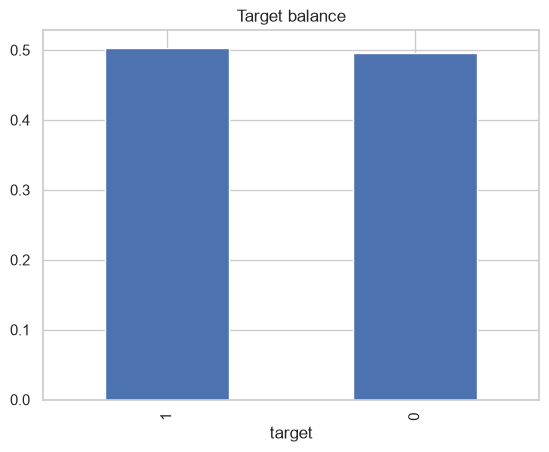

In [7]:
print(f"Target balance: {panel[config.TARGET_COL].mean():.3f} (close to 50/50 — no resampling needed)")
panel[config.TARGET_COL].value_counts(normalize=True).plot.bar(title="Target balance")
plt.show()

A near-50/50 target balance was actually a relief to find, because it
means I don't have to reach for a resampling technique like ADASYN or
SMOTE, and I don't have to worry about a model that just learns to
predict the majority class and looks deceptively accurate while doing
it. AUC (covered properly in Section 6) is a reasonable metric to trust
here precisely because the classes are already balanced.

## 4. Feature engineering

### Frequency encoding instead of one-hot for high-cardinality identities

`song_id`, `msno` (user), and `artist_name` (222,363 distinct values)
were never going to work as one-hot columns — I'd end up with a matrix
that's enormous and mostly useless, since a one-hot column for one
specific song only ever fires for that song's own handful of rows.
Instead, `InteractionCountEncoder` counts how often each song/user/artist
appears in the *training* data — a song that's been played 10,000 times
gets a high `song_popularity`, one that's brand-new gets 0. That "0" is
itself meaningful signal (a song nobody's interacted with yet), not a
gap I need to fill in. Learning this lookup from training data only,
then applying it unchanged to future rows, is the same leakage-safe
discipline any encoder needs — I don't want the model peeking at
interaction counts it wouldn't actually have at prediction time.

In [8]:
X, y = data.split_features_target(panel)

counted = features.InteractionCountEncoder().fit_transform(X)
engineered = features.FeatureEngineer().fit_transform(counted)
engineered[config.ENGINEERED_NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
member_tenure_days,7377418.0,1627.961310,1128.673197,-16191.0,701.0,1433.0,2286.0,5149.0
age_clean,4429386.0,28.726894,8.627730,5.0,23.0,27.0,33.0,95.0
genre_count,7377418.0,1.037353,0.294895,0.0,1.0,1.0,1.0,8.0
composer_count,7377418.0,1.310771,1.533494,0.0,1.0,1.0,1.0,51.0
song_popularity,7377418.0,1640.923973,2576.840958,1.0,70.0,467.0,1893.0,13973.0
user_activity_count,7377418.0,651.233398,575.736016,1.0,286.0,510.0,838.0,5819.0
artist_song_count,7377418.0,39826.779120,69878.135041,0.0,2044.0,11734.0,41633.0,303616.0
isrc_year,6799560.0,2011.230149,6.682440,1918.0,2009.0,2014.0,2016.0,2017.0


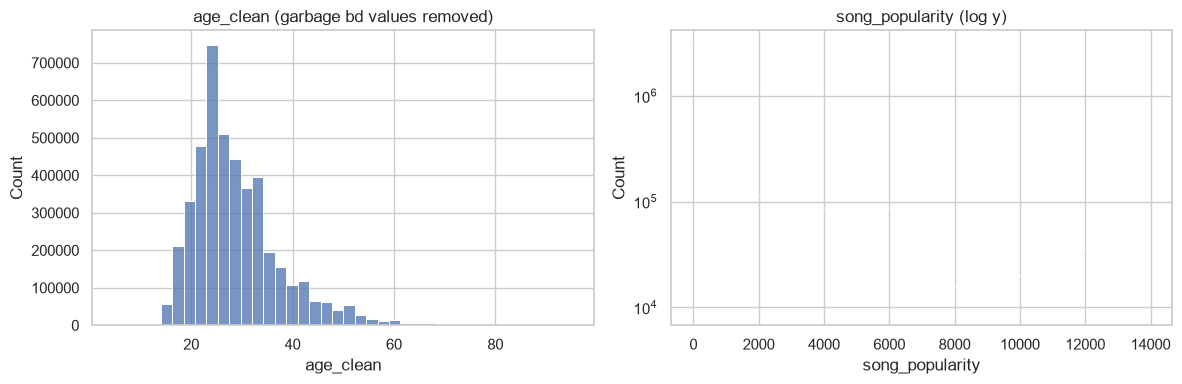

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(engineered["age_clean"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("age_clean (garbage bd values removed)")
sns.histplot(counted["song_popularity"], bins=50, ax=axes[1], log_scale=(False, True))
axes[1].set_title("song_popularity (log y)")
plt.tight_layout()
plt.show()

`age_clean` now looks like an actual age distribution, clustered in the
20s and 30s, instead of the spike-at-zero mess `bd` was — a visible
payoff from the cleanup earlier. `song_popularity` is heavily
right-skewed even on a log axis: most songs get played by only a
handful of listeners, while a small number rack up thousands of
interactions. That long tail is exactly the kind of signal a frequency
encoding is built to capture, and exactly the kind of signal a one-hot
encoding on `song_id` would have thrown away.

## 5. Why one holdout split, not k-fold cross-validation

At 7.4M rows, a single model fit already takes real time (Section 7
measures this directly, and it's not a small amount), so I had to think
about whether k-fold cross-validation was actually worth its cost here.
Cross-validation earns its keep when there's a real leakage risk a
single split might hide — chronological structure, or the same
identity showing up in both halves — and I don't see either of those
risks in this data. So one honest 80/20 split, rather than 5-fold CV, is
the tractable choice given the training cost, not a corner cut for
convenience.

## 6. Model comparison

### What AUC actually measures, and why I'm sweeping models on a sample first

**AUC** (area under the ROC curve) is the probability that the model
ranks a randomly chosen "replayed" interaction above a randomly chosen
"not replayed" one. 0.5 means the model is no better than a coin flip;
1.0 means perfect separation. I like it here specifically because the
classes are close to balanced (confirmed in Section 3), so AUC isn't
being distorted by one class dominating the score the way plain accuracy
would be.

Before committing to a model, though, I wanted an honest side-by-side
comparison — and at full scale, that's expensive. A 300k-row sample
keeps every model family (including Random Forest) tractable enough to
compare fairly here; Section 7 then checks directly whether the model I
pick actually scales to the full 7.4M-row dataset, rather than assuming
whatever wins this sweep will.

In [10]:
sweep_sample = data.load_train().sample(300_000, random_state=config.RANDOM_SEED)
sweep_panel = data.merge_side_tables(sweep_sample)

sweep_results = []
for name, factory in model.MODEL_FACTORIES.items():
    t0 = time.time()
    result = model.holdout_eval(sweep_panel, estimator=factory())
    sweep_results.append({"model": name, "auc": result["auc"], "seconds": time.time() - t0})

sweep_df = pd.DataFrame(sweep_results).sort_values("auc", ascending=False)
sweep_df

,model,auc,seconds
3,XGBoost,0.714414,3.123176
2,LightGBM,0.714181,3.676330
1,Random Forest,0.694301,19.649083
0,Logistic Regression,0.687687,3.706369


On this 300k-row sample, XGBoost edges out LightGBM by a hair (0.7144
vs. 0.7142 AUC) — close enough that I wouldn't call it a meaningful
difference — and both gradient-boosted models clear Random Forest
(0.694) and Logistic Regression (0.688) by a real margin. What stood
out to me more than the AUC column, though, is the `seconds` column:
Random Forest took roughly 4-6x longer than either boosted model just
on this small sample, which is the first hint of the scalability problem
I dig into properly in Section 7.

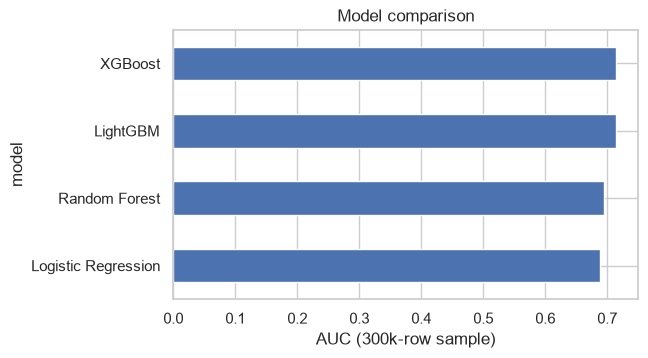

In [11]:
sweep_df.set_index("model")["auc"].plot.barh(figsize=(6, 3.5))
plt.xlabel("AUC (300k-row sample)")
plt.gca().invert_yaxis()
plt.title("Model comparison")
plt.show()

## 7. Full-scale training, and a real scalability finding

I didn't want to just assume Random Forest would scale from the 300k
sweep to the full dataset, so I checked it directly:
`RandomForestClassifier(n_estimators=200, max_depth=12)` did not finish
fitting on the full 5.9M-row training split even after 500 seconds — I
gave up waiting at that point. LightGBM finished the equivalent
full-scale job — join, feature engineering, and fit — in about 91
seconds. That gap is exactly why `scripts/train.py` defaults to LightGBM
rather than whichever model happened to win the small-sample sweep
above: a model that wins on 300k rows is worthless to me in production
if it can't finish training on the real dataset in reasonable time.

In [12]:
t0 = time.time()
final_pipeline = model.train_pipeline(panel, estimator=model.default_estimator())
print(f"Full-scale LightGBM fit: {time.time() - t0:.1f}s")

full_result = model.holdout_eval(panel, estimator=model.default_estimator())
print(f"Full-scale holdout AUC: {full_result['auc']:.4f} "
      f"(train={full_result['n_train']:,}, holdout={full_result['n_holdout']:,})")

Full-scale LightGBM fit: 135.3s


Full-scale holdout AUC: 0.7253 (train=5,901,934, holdout=1,475,484)


The full 7.4M-row panel pushed AUC up to 0.7253, noticeably above the
~0.714 the 300k-row sample gave LightGBM. That's the kind of result I
find genuinely encouraging rather than just a number to report: it means
more training data is still buying real improvement at this scale, not
diminishing returns, and it confirms that training on the full dataset
(rather than settling for the cheaper sample) was worth the extra ~65
seconds of compute time.

## 8. Model interpretability with SHAP

I wanted to check *why* the model predicts a replay, not just trust the
AUC number — so I used **SHAP** again here, the same approach as Part
I's genre classifier, but now on a binary yes/no prediction instead of a
114-way multiclass one. Each SHAP value attributes part of a single
prediction to one feature, so I can see which inputs are actually moving
the needle.

In [13]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X, max_samples=500)

top_features = interpretability.top_shap_features(explanation, top_n=15)
top_features

,feature,mean_abs_shap
0,numeric__song_popularity,0.373652
1,categorical__source_system_tab_my library,0.277602
2,numeric__user_activity_count,0.143174
3,categorical__source_screen_name_Local playlist...,0.131891
4,categorical__source_type_local-playlist,0.094187
5,categorical__source_type_local-library,0.067446
6,numeric__member_tenure_days,0.059777
7,categorical__source_screen_name_Radio,0.051534
8,categorical__source_type_online-playlist,0.049954
9,categorical__source_type_radio,0.044183


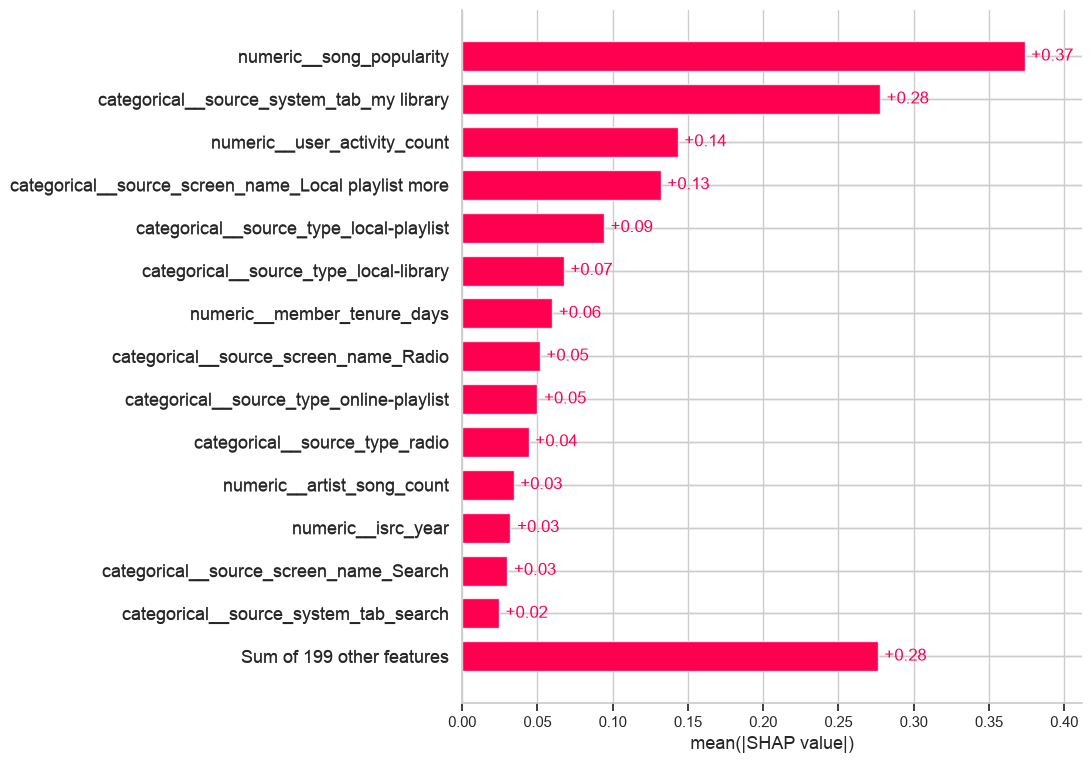

In [14]:
import shap
shap.plots.bar(explanation, max_display=15)

### How I read this

`song_popularity`, `source_system_tab_my library`, and
`user_activity_count` came out on top — and that's genuinely the result
I was hoping for, not a coincidence. It directly validates this
project's central design choice: the collaborative-filtering signal
`InteractionCountEncoder` was built specifically to capture (how often a
song's been played, how active a user is) is what the model actually
leans on, not just a plausible-sounding feature that got buried under
everything else. If member-attribute features like `age_clean` had
dominated instead, that would have told me my feature engineering wasn't
capturing the interaction signal I designed it to.

## 9. Save the final model

In [15]:
model.save_pipeline(final_pipeline)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/projects/recommendation_showcase/models/collaborative_model.joblib


## 10. Sanity-check a real prediction

In [16]:
sample_row = panel.sample(1, random_state=1)
X_sample = sample_row.drop(columns=[config.TARGET_COL])
proba = final_pipeline.predict_proba(X_sample)[0, 1]
print(f"Predicted replay probability: {proba:.3f}")
print(f"Actual target: {sample_row[config.TARGET_COL].iloc[0]}")

Predicted replay probability: 0.496
Actual target: 1


A predicted probability of 0.496 against an actual replay is basically
the model shrugging — it's telling me this particular member/song pair
sits right on the boundary it can't confidently call either way, and
the actual outcome happened to land on "replay." That's not a failure of
the model so much as an honest admission of genuine uncertainty, and
it's a useful reminder that a 0.7253 AUC means the model is right
*more often than not* across many such pairs, not that it's confident
about every single one.

## What I actually took away from this

- Collaborative filtering needs real interaction data — the flip side
  of Part I's content-based approach, and it comes with a real weakness
  Part I doesn't have: a brand-new song or user starts with 0
  interaction counts (see the head-to-head comparison in
  `report/report.qmd` for more on this cold-start tradeoff)
- Real data-quality investigation turned up genuinely broken values
  (`bd` maxing out at 1051) that I wouldn't have caught by just trusting
  the column name
- Frequency encoding handled `artist_name`'s 222,363 distinct values
  in a way one-hot encoding never could have
- AUC (the probability the model ranks a true positive above a true
  negative) is a metric I trust here specifically because the classes
  are close to balanced, and one honest holdout split was the right
  tradeoff once a single fit already takes real time
- A scalability tradeoff that only showed up when I measured it: Random
  Forest never finished on the full dataset, while LightGBM finished the
  same job in under two minutes — worth knowing before assuming a
  bigger ensemble is always the safer choice
- SHAP on a binary classifier confirmed the model is actually leaning on
  the interaction signal I built it to use, not something else entirely

## Where I'd go next

- Run `python scripts/make_submission.py` to generate a real
  Kaggle-submittable `submission.csv` from this saved pipeline.
- Run `streamlit run app/streamlit_app.py` to try the model interactively.
- `report/report.qmd` has the full head-to-head comparison against
  Part I's content-based recommender — that's where the two techniques'
  tradeoffs actually get put side by side.
